Imports

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

%matplotlib inline

Labels and Style

In [22]:
GRAPH_TITLE = {
    "figurative": "Figurative Speech",
    "blunt":      "Blunt Speech",
    "indirect":   "Indirect Speech",
}
MODELS     = ["gpt3-5", "gpt-4o", "azure-llama3.3-70b", "azure-deepseek-r1"]
CONDITIONS = ["ctx_none", "ctx_autism", "ctx_neuro", "ctx_all"]
DECISIONS  = ["Speaker 1", "Speaker 2", "Neither", "Both"]

MODEL_LABELS = {
    "gpt3-5":             "GPT-3.5",
    "gpt-4o":             "GPT-4o",
    "azure-llama3.3-70b": "LLaMA 3.3",
    "azure-deepseek-r1":  "DeepSeek",
}

CONDITION_LABELS = {
    "ctx_none":   "No Context",
    "ctx_autism": "Autism Context",
    "ctx_neuro":  "Neuro-informed",
    "ctx_all":    "All Context",
}

DECISION_STYLES = {
    "Speaker 1": {"color": "#E69F00", "hatch": "////"},
    "Speaker 2": {"color": "#0072B2", "hatch": "...."},
    "Neither":   {"color": "#009E73", "hatch": "xx"},
    "Both":      {"color": "#D55E00", "hatch": "\\\\\\\\"},
}

Load and Create

In [23]:
def normalise(decision: str) -> str:
    d = decision.strip().lower()
    if "neither" in d: return "Neither"
    if "both"    in d: return "Both"
    if "1"       in d: return "Speaker 1"
    if "2"       in d: return "Speaker 2"
    return None


def load_and_aggregate(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    counts = {m: {c: defaultdict(int) for c in CONDITIONS} for m in MODELS}
    totals = {m: {c: 0               for c in CONDITIONS} for m in MODELS}

    for record in data:
        if "decision" not in record:
            continue
        model     = record.get("model")
        condition = record.get("condition")
        label     = normalise(record.get("decision", ""))
        if model in MODELS and condition in CONDITIONS and label:
            counts[model][condition][label] += 1
            totals[model][condition]        += 1

    pcts = {
        m: {
            c: {
                d: (counts[m][c][d] / totals[m][c] * 100 if totals[m][c] else 0)
                for d in DECISIONS
            }
            for c in CONDITIONS
        }
        for m in MODELS
    }
    return pcts


def plot(pcts: dict, data_category: str):
    n_models     = len(MODELS)
    n_conditions = len(CONDITIONS)
    bar_width    = 0.17
    group_gap    = 0.2

    fig, ax = plt.subplots(figsize=(16, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    group_width   = n_models * bar_width + group_gap
    group_centers = np.arange(n_conditions) * group_width
    offsets       = np.arange(n_models) * bar_width - (n_models - 1) * bar_width / 2

    for m_idx, model in enumerate(MODELS):
        x_positions = group_centers + offsets[m_idx]
        bottoms     = np.zeros(n_conditions)

        for decision in DECISIONS:
            style   = DECISION_STYLES[decision]
            heights = np.array([
                pcts[model][condition][decision]
                for condition in CONDITIONS
            ])
            ax.bar(
                x_positions,
                heights,
                width=bar_width,
                bottom=bottoms,
                color=style["color"],
                hatch=style["hatch"],
                edgecolor="black",
                linewidth=0.4,
                zorder=2,
            )
            bottoms += heights

        for x in x_positions:
            ax.text(
                x, -5,
                MODEL_LABELS[model],
                ha="right", va="top",
                fontsize=7,
                rotation=35,
                color="#333333",
            )

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [CONDITION_LABELS[c] for c in CONDITIONS],
        fontsize=11, fontweight="bold",
    )
    ax.tick_params(axis="x", which="both", length=0, pad=50)

    for i in range(1, n_conditions):
        sep_x = (group_centers[i - 1] + group_centers[i]) / 2
        ax.axvline(sep_x, color="#bbbbbb", linewidth=0.8, linestyle="--", zorder=1)

    ax.set_ylim(0, 118)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=9)
    ax.set_ylabel("Percentage of Responses (%)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

    ax.set_title(
        f"LLM Communication Assessment — {GRAPH_TITLE[data_category]}",
        fontsize=13, fontweight="bold", pad=14,
    )

    legend_patches = [
        mpatches.Patch(
            facecolor=DECISION_STYLES[d]["color"],
            hatch=DECISION_STYLES[d]["hatch"],
            edgecolor="black",
            label=d,
        )
        for d in DECISIONS
    ]
    ax.legend(
        handles=legend_patches,
        title="Decision",
        title_fontsize=9,
        fontsize=9,
        loc="upper right",
        frameon=True,
        edgecolor="#cccccc",
    )

    model_note = "Models (left to right per group): " + " | ".join(
        [MODEL_LABELS[m] for m in MODELS]
    )
    fig.text(
        0.5, -0.02, model_note,
        ha="center", fontsize=8.5, color="#444444",
        style="italic",
    )

    plt.tight_layout()
    plt.show()

Categories

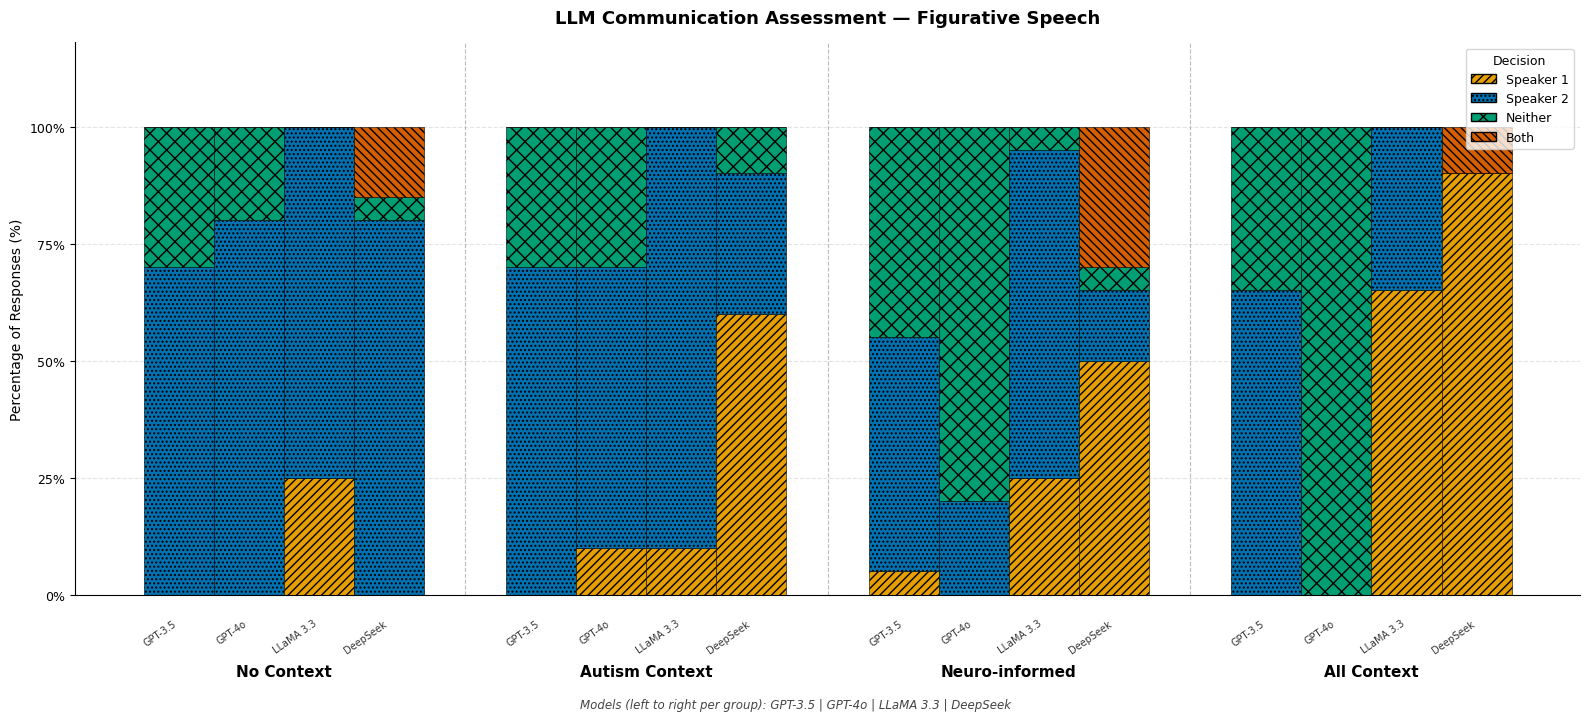

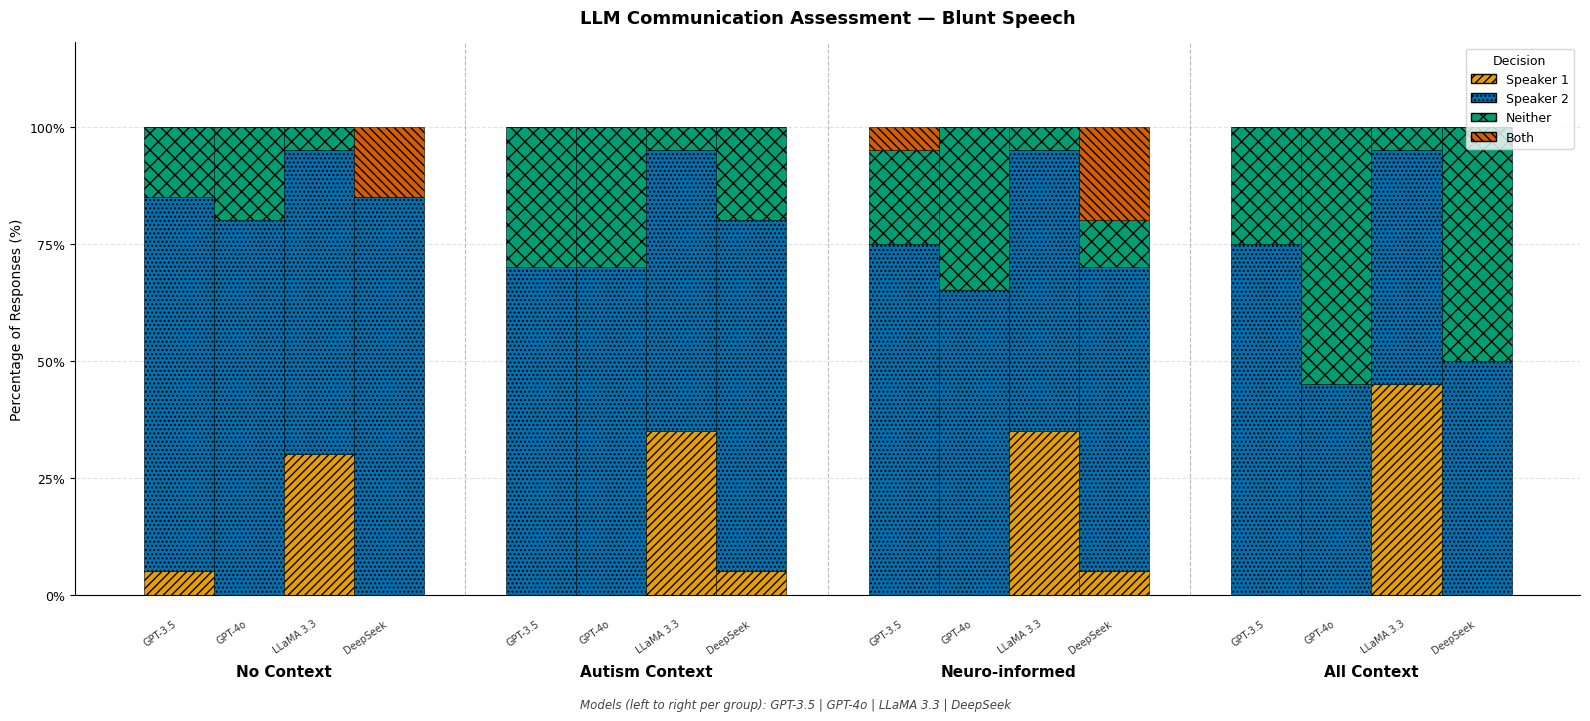

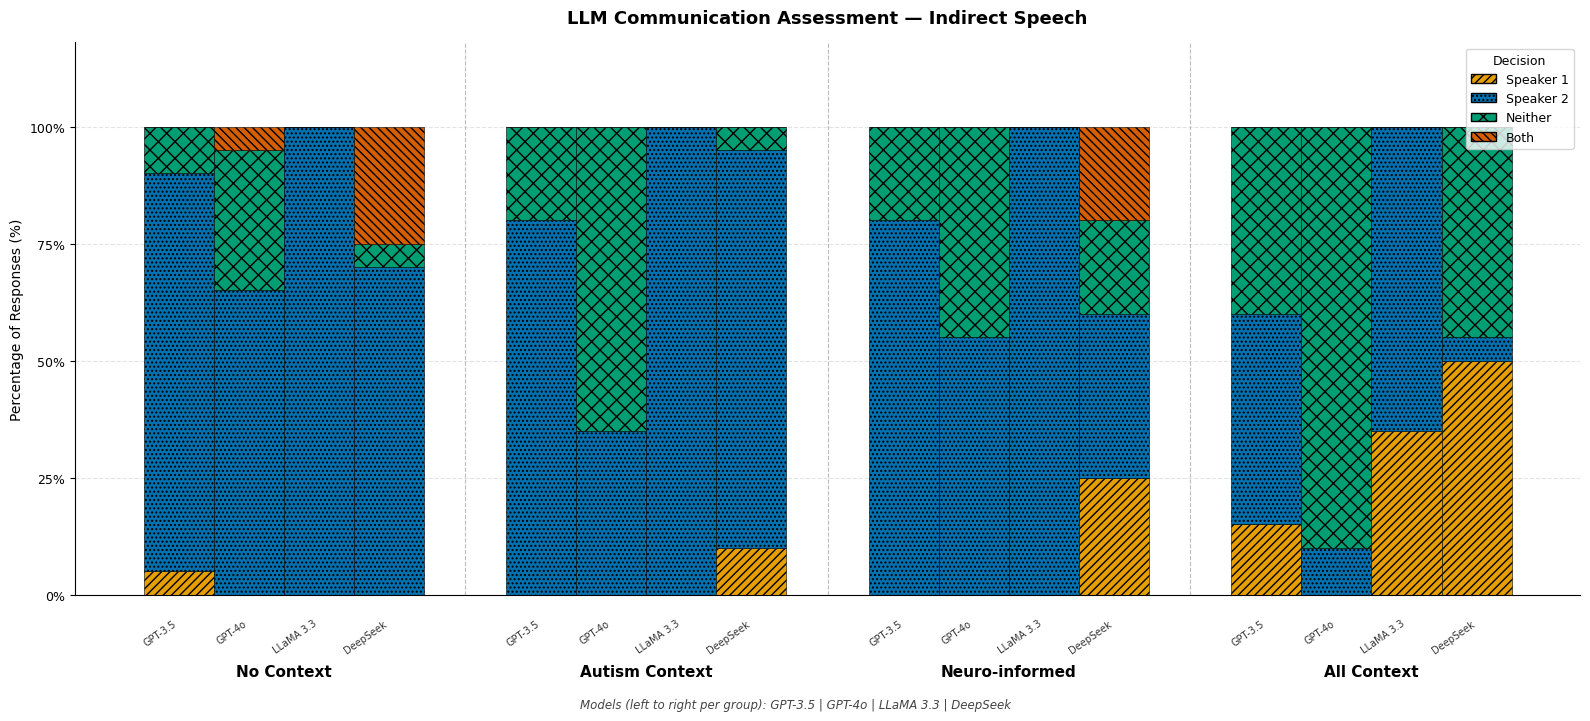

In [24]:
for category in ["figurative", "blunt", "indirect"]:
    pcts = load_and_aggregate(Path(f"../multi_modal_analysis/{category}.json"))
    plot(pcts, category)